## Smart Selection Experiments

**Goal:** Test top non-Attention models dengan top feature strategies

**Models (4):**
- Optimized (base LSTM)
- CIFG (Coupled Input-Forget Gate)
- Peephole (gates peek at cell state)
- Nested (hierarchical)

**Feature Strategies (3):**
- service_moderate (f=13)
- service_full (f=18)
- ultimate (f=19)

**Total: 12 experiments**

In [7]:
# Import Libraries
import numpy as np
import pandas as pd
import os
import sys
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, confusion_matrix
from imblearn.over_sampling import SMOTE

# Import models
sys.path.insert(0, os.path.join(os.getcwd(), '..'))  # project root
from src.model.lstm_cupy_optimized import LSTMModelGPUOptimized
from src.model.lstm_cifg import CIFGLSTMModelGPUOptimized
from src.model.lstm_peephole import PeepholeLSTMModelGPUOptimized
from src.model.lstm_nested import NestedLSTMModelGPUOptimized
from src.utils.model_io import save_model

# Model registry - Only the 4 selected models
MODEL_REGISTRY = {
    'Optimized': LSTMModelGPUOptimized,
    'CIFG': CIFGLSTMModelGPUOptimized,
    'Peephole': PeepholeLSTMModelGPUOptimized,
    'Nested': NestedLSTMModelGPUOptimized,
}

CHECKPOINT_PATH = os.path.join(os.getcwd(), '..', 'src/model/checkpoints/')
print(f"Models to test: {list(MODEL_REGISTRY.keys())}")

Models to test: ['Optimized', 'CIFG', 'Peephole', 'Nested']


In [8]:
# === 1. Load Data ===
DATA_DIR = os.path.join(os.getcwd(), '..', 'data')
RAW_DATA = os.path.join(DATA_DIR, 'raw_dataset.csv')
df = pd.read_csv(RAW_DATA)

# Check GPU
try:
    import cupy as cp
    print("GPU acceleration enabled")
except ImportError:
    print("CPU mode")

GPU acceleration enabled


In [9]:
# === 2. Preprocess & Feature Engineering ===
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df[df['Type'].str.contains('restoration', case=False, na=False)]
df['Priority'] = pd.to_numeric(df['Priority'], errors='coerce')
df['Impact'] = pd.to_numeric(df['Impact'], errors='coerce')
df['incident'] = ((df['Priority'] >= 2) & (df['Impact'] >= 2)).astype(int)

print("Creating all features...")

# Temporal
df['hour'] = df['Timestamp'].dt.hour
df['day_of_week'] = df['Timestamp'].dt.dayofweek

# Interactions
df['priority_impact_product'] = df['Priority'] * df['Impact']
df['priority_impact_sum'] = df['Priority'] + df['Impact']
df['risk_score'] = (0.6 * df['Priority']) + (0.4 * df['Impact'])
df['priority_squared'] = df['Priority'] ** 2
df['impact_squared'] = df['Impact'] ** 2
df['priority_hour_interaction'] = df['Priority'] * df['hour']
df['impact_hour_interaction'] = df['Impact'] * df['hour']
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Service features
service_incident_rates = df.groupby('Service Type')['incident'].mean()
df['service_risk_score'] = df['Service Type'].map(service_incident_rates)
service_freq = df['Service Type'].value_counts(normalize=True)
df['service_frequency'] = df['Service Type'].map(service_freq)
name_incident_rates = df.groupby('Service Name')['incident'].mean()
df['service_name_risk'] = df['Service Name'].map(name_incident_rates)
df['service_risk_score'] = df['service_risk_score'].fillna(df['service_risk_score'].mean())
df['service_frequency'] = df['service_frequency'].fillna(0)
df['service_name_risk'] = df['service_name_risk'].fillna(df['service_name_risk'].mean())

# Sequence features
df['priority_volatility'] = df['Priority'].rolling(window=4, min_periods=1).std().fillna(0).clip(0, 5)
df['impact_volatility'] = df['Impact'].rolling(window=4, min_periods=1).std().fillna(0).clip(0, 5)
df['priority_change'] = df['Priority'].diff().fillna(0)
df['impact_change'] = df['Impact'].diff().fillna(0)
df['incidents_last_2h'] = df['incident'].rolling(window=4, min_periods=1).sum()
df['consecutive_high_priority'] = (df['Priority'] >= 2).rolling(window=6, min_periods=1).sum()
df['priority_acceleration'] = df['Priority'].diff().diff().fillna(0)

print(f"Dataset shape: {df.shape}")

Creating all features...
Dataset shape: (18969, 36)


In [10]:
# === 3. Feature Strategies ===
FEATURE_STRATEGIES = {
    'service_moderate': [
        'Priority', 'Impact',
        'priority_impact_product', 'priority_impact_sum', 'risk_score',
        'priority_squared', 'impact_squared',
        'priority_hour_interaction', 'impact_hour_interaction',
        'hour_sin', 'hour_cos',
        'service_risk_score', 'service_frequency'
    ],  # f=13
    
    'service_full': [
        'Priority', 'Impact',
        'priority_impact_product', 'priority_impact_sum', 'risk_score',
        'priority_squared', 'impact_squared',
        'priority_hour_interaction', 'impact_hour_interaction',
        'hour_sin', 'hour_cos',
        'day_sin', 'day_cos',
        'hour', 'day_of_week',
        'service_risk_score', 'service_frequency', 'service_name_risk'
    ],  # f=18
    
    'ultimate': [
        'Priority', 'Impact',
        'priority_impact_product', 'priority_impact_sum', 'risk_score',
        'priority_squared', 'impact_squared',
        'priority_hour_interaction', 'impact_hour_interaction',
        'hour_sin', 'hour_cos',
        'service_risk_score', 'service_frequency',
        'priority_volatility', 'impact_volatility',
        'incidents_last_2h', 'consecutive_high_priority',
        'priority_change', 'priority_acceleration'
    ]  # f=19
}

print("Feature strategies:")
for name, features in FEATURE_STRATEGIES.items():
    print(f"  {name}: {len(features)} features")

Feature strategies:
  service_moderate: 13 features
  service_full: 18 features
  ultimate: 19 features


In [11]:
# === 4. Helper Functions ===
def create_windowed_dataset(df, feature_cols, target_col, window_size):
    X, y = [], []
    for i in range(len(df) - window_size):
        window = df[feature_cols].iloc[i:i+window_size].astype(float).values
        label = df[target_col].iloc[i+window_size]
        X.append(window)
        y.append(label)
    return np.array(X), np.array(y)

def train_eval(X, y, label, model_type, hidden_size=128, patience=5, epochs=500, batch_size=128, lr=0.001, print_every=10):
    """Train and evaluate model"""
    # Split: 60/20/20
    X_temp, X_te, y_temp, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    X_tr, X_val, y_tr, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)
    
    input_size = X.shape[2]
    ModelClass = MODEL_REGISTRY[model_type]
    model = ModelClass(input_size=input_size, hidden_size=hidden_size, cw=1)
    
    start_time = time.time()
    history = model.train(X_tr, y_tr, X_val, y_val, epochs=epochs, batch_size=batch_size, 
                          lr=lr, print_every=print_every, patience=patience, lambda_l2=0.0001)
    duration = time.time() - start_time
    
    # Evaluate
    y_prob = model.predict(X_te, batch_size=batch_size)
    y_prob = y_prob.flatten() if hasattr(y_prob, 'flatten') else y_prob
    y_pred = (y_prob >= 0.5).astype(int)
    
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    auc_score = auc(fpr, tpr)
    
    # Save model
    checkpoint_name = f"lstm_{model_type.lower()}_{label.replace('|', '_').replace('=', '')}.pkl"
    checkpoint_path = os.path.join(CHECKPOINT_PATH, checkpoint_name)
    save_model(model, checkpoint_path)
    
    return {
        'Model': label,
        'ModelType': model_type,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall': recall_score(y_te, y_pred, zero_division=0),
        'F1_Score': f1_score(y_te, y_pred, zero_division=0),
        'AUC': auc_score,
        'TrainingTime': duration,
        'y_test': y_te,
        'y_pred': y_pred,
        'y_prob': y_prob
    }

def save_model_assets(result, output_base_path="../data/output"):
    """Save metrics and plots"""
    model_name = result['Model']
    folder_name = model_name.replace('|', '_').replace('=', '')
    model_dir = os.path.join(output_base_path, folder_name)
    os.makedirs(model_dir, exist_ok=True)

    y_true = result['y_test']
    y_prob = result['y_prob']
    
    # Find optimum threshold
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
    opt_idx = np.argmax(f1_scores)
    opt_threshold = float(thresholds[opt_idx]) if opt_idx < len(thresholds) else 0.5
    y_pred_opt = (y_prob >= opt_threshold).astype(int)
    pr_auc = average_precision_score(y_true, y_prob)

    # Save CSV
    save_data = {
        'Model': model_name,
        'ROC_AUC': result['AUC'],
        'PR_AUC': pr_auc,
        'TrainingTime': result['TrainingTime'],
        'Std_Threshold': 0.5,
        'Std_Accuracy': result['Accuracy'],
        'Std_Precision': result['Precision'],
        'Std_Recall': result['Recall'],
        'Std_F1': result['F1_Score'],
        'Opt_Threshold': opt_threshold,
        'Opt_Accuracy': accuracy_score(y_true, y_pred_opt),
        'Opt_Precision': precision_score(y_true, y_pred_opt),
        'Opt_Recall': recall_score(y_true, y_pred_opt),
        'Opt_F1': f1_score(y_true, y_pred_opt),
    }
    csv_path = os.path.join(model_dir, f"metrics_{folder_name}.csv")
    pd.DataFrame([save_data]).to_csv(csv_path, index=False)
    
    # Save arrays
    np.save(os.path.join(model_dir, f"y_test_{folder_name}.npy"), y_true)
    np.save(os.path.join(model_dir, f"y_prob_{folder_name}.npy"), y_prob)
    
    print(f"      Saved to: {model_dir}")

In [12]:
# === 5. Run Smart Selection Experiments ===

# Config
SAMPLING_PERIOD = '30min'
WINDOW_SIZE = 48

models_to_test = ['Optimized', 'CIFG', 'Peephole', 'Nested']
strategies_to_test = ['service_moderate', 'service_full', 'ultimate']

total_experiments = len(models_to_test) * len(strategies_to_test)
print(f"\n{'='*70}")
print(f"SMART SELECTION EXPERIMENTS")
print(f"{'='*70}")
print(f"Models: {models_to_test}")
print(f"Strategies: {strategies_to_test}")
print(f"Total experiments: {total_experiments}")
print(f"{'='*70}\n")

all_results = []
experiment_num = 0

for strategy_name in strategies_to_test:
    feature_cols = FEATURE_STRATEGIES[strategy_name]
    n_features = len(feature_cols)
    
    print(f"\n{'='*60}")
    print(f"Strategy: {strategy_name} (f={n_features})")
    print(f"{'='*60}")
    
    # Aggregate
    agg_dict = {'incident': 'sum'}
    for feature in feature_cols:
        if feature in ['hour', 'day_of_week']:
            agg_dict[feature] = 'first'
        else:
            agg_dict[feature] = 'mean'
    
    df_resampled = (df.set_index('Timestamp')
                      .resample(SAMPLING_PERIOD)
                      .agg(agg_dict)
                      .fillna(0)
                      .reset_index())
    df_resampled['incident'] = (df_resampled['incident'] > 0).astype(int)
    
    # Create windowed dataset
    X, y = create_windowed_dataset(df_resampled, feature_cols, 'incident', WINDOW_SIZE)
    print(f"  Data: {len(X)} samples")
    
    # SMOTE
    X_flat = X.reshape((X.shape[0], -1))
    X_sm, y_sm = SMOTE(random_state=42).fit_resample(X_flat, y)
    Xs = X_sm.reshape((-1, WINDOW_SIZE, n_features))
    print(f"  After SMOTE: {len(Xs)} samples")
    
    # Test each model
    for model_type in models_to_test:
        experiment_num += 1
        label = f"{SAMPLING_PERIOD}|win={WINDOW_SIZE}|f={n_features}-{strategy_name}-{model_type}"
        
        print(f"\n  [{experiment_num}/{total_experiments}] {model_type}")
        
        try:
            result = train_eval(Xs, y_sm, label=label, model_type=model_type, print_every=20)
            result['strategy'] = strategy_name
            result['n_features'] = n_features
            all_results.append(result)
            save_model_assets(result)
            
            print(f"      F1={result['F1_Score']:.4f} | AUC={result['AUC']:.4f}")
            
        except Exception as e:
            print(f"      FAILED: {e}")
            import traceback
            traceback.print_exc()

print(f"\n{'='*70}")
print(f"COMPLETED: {len(all_results)}/{total_experiments} experiments")
print(f"{'='*70}")


SMART SELECTION EXPERIMENTS
Models: ['Optimized', 'CIFG', 'Peephole', 'Nested']
Strategies: ['service_moderate', 'service_full', 'ultimate']
Total experiments: 12


Strategy: service_moderate (f=13)
  Data: 14592 samples
  After SMOTE: 20224 samples

  [1/12] Optimized
Training: 12134 samples, 95 batches/epoch, batch_size=128
Validation: 4045 samples | Early stopping patience: 5
----------------------------------------------------------------------
Epoch   20/500 | Train Loss: 0.3594 | Val Loss: 0.3612 | Val Acc: 0.7985

🛑 Early stopping triggered at epoch 27
----------------------------------------------------------------------
Final - Train Loss: 0.3540 | Val Loss: 0.3586 | Val Acc: 0.7960
✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_optimized_30min_win48_f13-service_moderate-Optimized.pkl
      Saved to: ../data/output\30min_win48_f13-service_moderate-Optimized
      F1=0.8182 | AUC=0.9075

  [2/1

In [13]:
# === 6. Results Summary ===

res_df = pd.DataFrame(all_results)
res_df = res_df.sort_values('F1_Score', ascending=False).reset_index(drop=True)

print("\n" + "="*90)
print("SMART SELECTION RESULTS (Sorted by F1)")
print("="*90)

display_cols = ['ModelType', 'strategy', 'n_features', 'F1_Score', 'Precision', 'Recall', 'AUC', 'TrainingTime']
print(res_df[display_cols].to_string(index=False))

# Summary by model type
print("\n" + "="*90)
print("SUMMARY BY MODEL TYPE")
print("="*90)
model_summary = res_df.groupby('ModelType').agg({
    'F1_Score': ['mean', 'max'],
    'AUC': 'mean'
}).round(4)
model_summary.columns = ['Mean_F1', 'Max_F1', 'Mean_AUC']
model_summary = model_summary.sort_values('Max_F1', ascending=False)
print(model_summary)

# Summary by strategy
print("\n" + "="*90)
print("SUMMARY BY FEATURE STRATEGY")
print("="*90)
strategy_summary = res_df.groupby('strategy').agg({
    'F1_Score': ['mean', 'max'],
    'AUC': 'mean'
}).round(4)
strategy_summary.columns = ['Mean_F1', 'Max_F1', 'Mean_AUC']
strategy_summary = strategy_summary.sort_values('Max_F1', ascending=False)
print(strategy_summary)


SMART SELECTION RESULTS (Sorted by F1)
ModelType         strategy  n_features  F1_Score  Precision   Recall      AUC  TrainingTime
Optimized     service_full          18  0.821005   0.838577 0.804154 0.909404    455.097553
   Nested     service_full          18  0.820005   0.866263 0.778437 0.910217   2067.121896
     CIFG         ultimate          19  0.819401   0.856526 0.785361 0.909129    516.179746
     CIFG service_moderate          13  0.818602   0.851872 0.787834 0.907282    449.597963
Optimized service_moderate          13  0.818229   0.853383 0.785856 0.907455   1194.805132
 Peephole     service_full          18  0.817844   0.883028 0.761622 0.908832   1013.097543
 Peephole         ultimate          19  0.817382   0.856833 0.781405 0.909111   1054.324536
Optimized         ultimate          19  0.816754   0.867631 0.771513 0.909369    762.508362
     CIFG     service_full          18  0.814893   0.867188 0.768546 0.908914    678.479908
   Nested service_moderate          13  

In [14]:
# === 7. Comparison with Attention Baseline ===

print("\n" + "="*90)
print("COMPARISON WITH ATTENTION BASELINE")
print("="*90)
print("\nAttention baseline (from previous experiments):")
print("  service_moderate (f=13): F1 = 0.8239")
print("  service_full (f=18):     F1 = 0.8194")
print("  ultimate (f=19):         F1 = 0.8052")

print("\nNew results:")
for _, row in res_df.iterrows():
    baseline = {'service_moderate': 0.8239, 'service_full': 0.8194, 'ultimate': 0.8052}
    diff = row['F1_Score'] - baseline.get(row['strategy'], 0)
    sign = '+' if diff > 0 else ''
    print(f"  {row['ModelType']:12} ({row['strategy']:16}): F1 = {row['F1_Score']:.4f} ({sign}{diff:.4f} vs Attention)")


COMPARISON WITH ATTENTION BASELINE

Attention baseline (from previous experiments):
  service_moderate (f=13): F1 = 0.8239
  service_full (f=18):     F1 = 0.8194
  ultimate (f=19):         F1 = 0.8052

New results:
  Optimized    (service_full    ): F1 = 0.8210 (+0.0016 vs Attention)
  Nested       (service_full    ): F1 = 0.8200 (+0.0006 vs Attention)
  CIFG         (ultimate        ): F1 = 0.8194 (+0.0142 vs Attention)
  CIFG         (service_moderate): F1 = 0.8186 (-0.0053 vs Attention)
  Optimized    (service_moderate): F1 = 0.8182 (-0.0057 vs Attention)
  Peephole     (service_full    ): F1 = 0.8178 (-0.0016 vs Attention)
  Peephole     (ultimate        ): F1 = 0.8174 (+0.0122 vs Attention)
  Optimized    (ultimate        ): F1 = 0.8168 (+0.0116 vs Attention)
  CIFG         (service_full    ): F1 = 0.8149 (-0.0045 vs Attention)
  Nested       (service_moderate): F1 = 0.8144 (-0.0095 vs Attention)
  Nested       (ultimate        ): F1 = 0.8141 (+0.0089 vs Attention)
  Peephole    

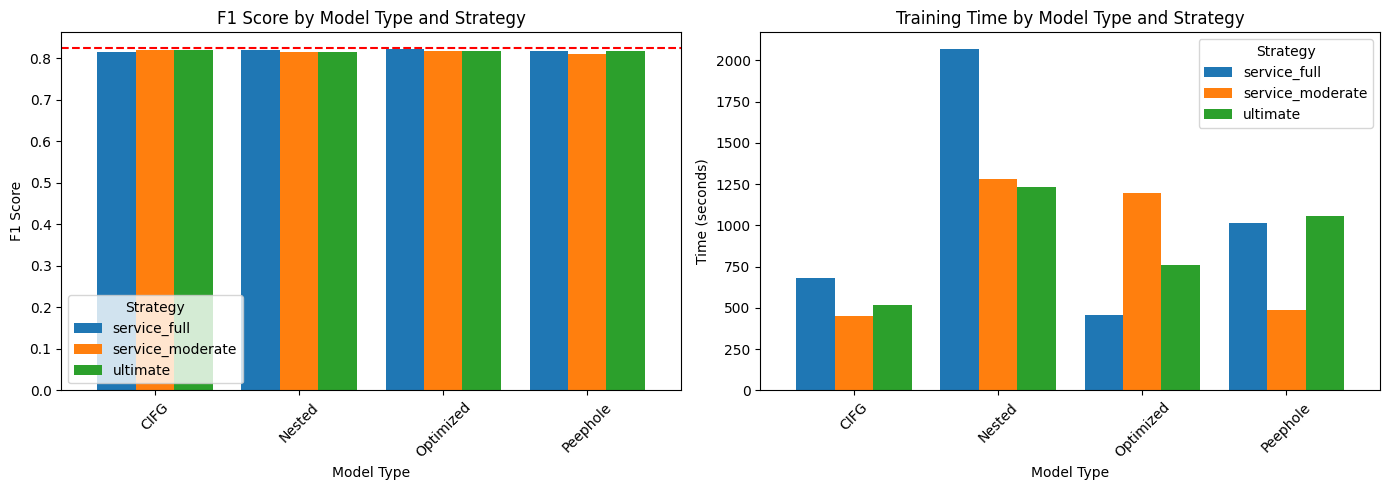

In [15]:
# === 8. Visualization ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 by Model Type
pivot_f1 = res_df.pivot(index='ModelType', columns='strategy', values='F1_Score')
pivot_f1.plot(kind='bar', ax=axes[0], width=0.8)
axes[0].set_title('F1 Score by Model Type and Strategy')
axes[0].set_ylabel('F1 Score')
axes[0].set_xlabel('Model Type')
axes[0].legend(title='Strategy')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(y=0.8239, color='red', linestyle='--', label='Attention baseline')

# Training Time
pivot_time = res_df.pivot(index='ModelType', columns='strategy', values='TrainingTime')
pivot_time.plot(kind='bar', ax=axes[1], width=0.8)
axes[1].set_title('Training Time by Model Type and Strategy')
axes[1].set_ylabel('Time (seconds)')
axes[1].set_xlabel('Model Type')
axes[1].legend(title='Strategy')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()